# 07. KKBOX 전이 테스트 & KKBOX 단독 학습/예측

이 노트북은 두 가지 실험을 수행한다.

**실험 A. 전이 테스트 (Transfer)** 
- `06`의 최종 모델(Stacking)을 Netflix 데이터로 학습한 뒤 KKBOX 데이터로 예측
- 동일 피처 구조에서 모델이 다른 도메인으로 일반화되는지 검증

**실험 B. KKBOX 단독 학습 (In-domain)** 
- KKBOX 데이터만으로 동일 파이프라인 학습 후 평가
- 실제 데이터에서 모델 성능 상한을 확인

사용 파일:
- `netflix_user_behavior_churn_50000v2.csv`
- `kkbox_netflix_format.csv`

## 1. 라이브러리 임포트

In [3]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
    classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings('ignore')

def resolve_project_path(*parts):
    """노트북을 repo 루트/ notebooks 어디서 실행해도 같은 파일을 찾는다."""
    candidates = [Path(*parts), Path('..', *parts)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {Path(*parts)}")


def project_output_dir():
    output_dir = Path('../outputs') if Path('../outputs').exists() else Path('outputs')
    output_dir.mkdir(exist_ok=True)
    return output_dir


font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((f for f in font_candidates if f in available_fonts), None)
if font_name:
    plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

## 2. 공통 유틸리티 함수

In [4]:
def sample_by_churn_ratio(df, target_col='churned',
                           n_total=10000, churn_ratio=0.3,
                           random_state=42):
    """
    churned 컬럼 비율을 조절하여 원하는 크기로 샘플링

    Parameters
    ----------
    df           : 원본 DataFrame
    target_col   : 이탈 타겟 컬럼명
    n_total      : 샘플링 총 개수
    churn_ratio  : 이탈자 비율 0.0~1.0
    random_state : 재현성 시드

    Returns
    -------
    df_sample : 샘플링된 DataFrame (index 초기화)
    """
    n_churn     = int(n_total * churn_ratio)
    n_non_churn = n_total - n_churn

    churn_pool     = df[df[target_col] == 1]
    non_churn_pool = df[df[target_col] == 0]

    replace_churn = n_churn     > len(churn_pool)
    replace_non   = n_non_churn > len(non_churn_pool)

    if replace_churn:
        print(f"이탈자 요청({n_churn}) > 가용({len(churn_pool)}) → replace=True")
    if replace_non:
        print(f"유지자 요청({n_non_churn}) > 가용({len(non_churn_pool)}) → replace=True")

    sample_churn = churn_pool.sample(n=n_churn, replace=replace_churn, random_state=random_state)
    sample_non   = non_churn_pool.sample(n=n_non_churn, replace=replace_non, random_state=random_state)

    df_sample = (pd.concat([sample_churn, sample_non])
                   .sample(frac=1, random_state=random_state)
                   .reset_index(drop=True))

    actual = df_sample[target_col].mean()
    print(f"샘플링 완료 | 총 {len(df_sample):,}행 "
          f"| 이탈 {df_sample[target_col].sum():,}명({actual*100:.1f}%) "
          f"| 유지 {(df_sample[target_col]==0).sum():,}명({(1-actual)*100:.1f}%)")

    return df_sample


def preprocess(df, le_dict=None, fit=True):
    """
    전처리: 불필요 컬럼 제거 → LabelEncoding → 피처/타겟 분리

    Parameters
    ----------
    df      : 원본 DataFrame
    le_dict : LabelEncoder 딕셔너리 (fit=False일 때 필수)
    fit     : True이면 LabelEncoder를 새로 fit, False이면 le_dict를 그대로 사용

    Returns
    -------
    X, y, le_dict
    """
    DROP_COLS   = ['user_id', 'gender', 'region', 'favorite_genre',
                   'time_of_day', 'churned']
    CAT_COLS    = ['subscription_type', 'payment_method',
                   'primary_device', 'recommendation_source']

    df = df.copy()
    y  = df['churned'].copy()
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    if fit:
        le_dict = {}
        for col in CAT_COLS:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            le_dict[col] = le
    else:
        for col in CAT_COLS:
            le = le_dict[col]
            # 학습 시 없던 값은 최빈값으로 대체
            df[col] = df[col].astype(str).map(
                lambda v, le=le: le.transform([v])[0]
                if v in le.classes_ else le.transform([le.classes_[0]])[0]
            )

    return df, y, le_dict


def build_stacking():
    """06 노트북과 동일한 Stacking 구조 반환"""
    base_estimators = [
        ('lgbm', LGBMClassifier(
            n_estimators=500, max_depth=7, learning_rate=0.03,
            num_leaves=127, subsample=0.85, colsample_bytree=0.85,
            min_child_samples=10, reg_alpha=0.05, reg_lambda=0.5,
            random_state=42, verbose=-1
        )),
        ('xgb', XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.03,
            subsample=0.85, colsample_bytree=0.85,
            min_child_weight=3, gamma=0.1,
            reg_alpha=0.05, reg_lambda=0.5,
            eval_metric='logloss', verbosity=0, random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_split=2,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1
        )),
    ]
    meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    return StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_model,
        cv=3,
        passthrough=False,
        n_jobs=-1
    )


def evaluate(y_true, y_prob, threshold=0.66, label=''):
    """threshold 기준 분류 지표 출력"""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'threshold':  threshold,
        'accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'precision':  round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':     round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1':         round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':    round(roc_auc_score(y_true, y_prob), 4),
    }
    print(f'\n=== {label} 평가 결과 (threshold={threshold}) ===')
    display(pd.DataFrame([metrics]))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=ax)
    ax.set_title(f'{label} | threshold={threshold}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics


def find_best_threshold(y_true, y_prob, metric='f1'):
    """임계값별 지표를 탐색해 최적값 반환"""
    rows = []
    for t in np.arange(0.25, 0.80, 0.05):
        yp = (y_prob >= t).astype(int)
        rows.append({
            'threshold':  round(t, 2),
            'precision':  precision_score(y_true, yp, zero_division=0),
            'recall':     recall_score(y_true, yp, zero_division=0),
            'f1':         f1_score(y_true, yp, zero_division=0),
            'roc_auc':    roc_auc_score(y_true, y_prob),
        })
    df_thresh = pd.DataFrame(rows)
    best_th   = df_thresh.loc[df_thresh[metric].idxmax(), 'threshold']
    print(f'\n최적 threshold ({metric} 기준): {best_th}')
    display(df_thresh)
    return best_th, df_thresh

---
# 실험 A. Netflix → KKBOX 전이 테스트

Netflix 데이터로 Stacking 모델을 학습하고, KKBOX 데이터로 예측해 도메인 전이 가능성을 검증한다.

## A-1. 데이터 로드 및 샘플링

In [5]:
NETFLIX_PATH = resolve_project_path('data', 'user_behavior_50000', 'netflix_user_behavior_churn_50000v2.csv')
KKBOX_PATH   = resolve_project_path('data', 'KKBOX', 'kkbox_netflix_format.csv')

# Netflix
print('[Netflix]')
df_netflix_ori = pd.read_csv(NETFLIX_PATH)
df_netflix = sample_by_churn_ratio(df_netflix_ori, n_total=10000, churn_ratio=0.3)

# KKBOX
print('\n[KKBOX]')
df_kkbox_ori = pd.read_csv(KKBOX_PATH)
df_kkbox = sample_by_churn_ratio(df_kkbox_ori, n_total=10000, churn_ratio=0.3)

[Netflix]
샘플링 완료 | 총 10,000행 | 이탈 3,000명(30.0%) | 유지 7,000명(70.0%)

[KKBOX]
샘플링 완료 | 총 10,000행 | 이탈 3,000명(30.0%) | 유지 7,000명(70.0%)


## A-2. Netflix 전처리 및 학습

In [6]:
# 전처리
X_net, y_net, le_dict = preprocess(df_netflix, fit=True)

# 학습 / 테스트 분할
X_train, X_test_net, y_train, y_test_net = train_test_split(
    X_net, y_net, test_size=0.3, random_state=2026, stratify=y_net
)

# BorderlineSMOTE
X_res, y_res = BorderlineSMOTE(random_state=42).fit_resample(X_train, y_train)
print(f'학습 데이터: {X_res.shape} | 이탈: {y_res.sum()}')

# 컬럼 순서 저장 (KKBOX 정렬에 사용)
TRAIN_COLS = X_res.columns.tolist()

학습 데이터: (9800, 14) | 이탈: 4900


In [7]:
# Stacking 모델 학습
print('Stacking 학습 중...')
stacking = build_stacking()
stacking.fit(X_res, y_res)
print('학습 완료')

Stacking 학습 중...
학습 완료


## A-3. Netflix 테스트셋 평가 (기준값)


최적 threshold (f1 기준): 0.4


,threshold,precision,recall,f1,roc_auc
0,0.25,0.591454,0.876667,0.706356,0.895281
1,0.30,0.608558,0.853333,0.710453,0.895281
2,0.35,0.633389,0.838889,0.721797,0.895281
3,0.40,0.651904,0.817778,0.725481,0.895281
4,0.45,0.667290,0.793333,0.724873,0.895281
5,0.50,0.683794,0.768889,0.723849,0.895281
6,0.55,0.698846,0.740000,0.718834,0.895281
7,0.60,0.716022,0.720000,0.718006,0.895281
8,0.65,0.732639,0.703333,0.717687,0.895281
9,0.70,0.745455,0.683333,0.713043,0.895281



=== Netflix (기준) 평가 결과 (threshold=0.66) ===


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.66,0.8353,0.7377,0.7,0.7184,0.8953


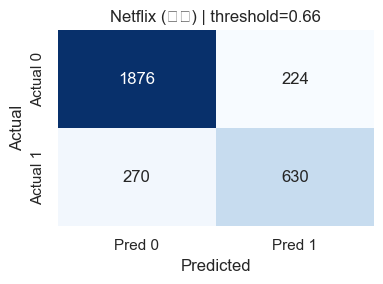

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      2100
           1       0.74      0.70      0.72       900

    accuracy                           0.84      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.83      0.84      0.83      3000



In [8]:
prob_net = stacking.predict_proba(X_test_net)[:, 1]

# 최적 threshold 탐색
best_th_net, thresh_df_net = find_best_threshold(y_test_net, prob_net, metric='f1')

# 06 노트북 threshold=0.66 기준 평가
metrics_net = evaluate(y_test_net, prob_net, threshold=0.66, label='Netflix (기준)')

## A-4. KKBOX 전처리 및 피처 정렬

In [9]:
# Netflix와 동일한 LabelEncoder로 transform (fit=False)
X_kkbox, y_kkbox, _ = preprocess(df_kkbox, le_dict=le_dict, fit=False)

# 학습 컬럼 순서에 맞게 정렬 (없는 컬럼은 0으로 채움)
X_kkbox_aligned = pd.DataFrame(0, index=X_kkbox.index, columns=TRAIN_COLS)
for col in TRAIN_COLS:
    if col in X_kkbox.columns:
        X_kkbox_aligned[col] = X_kkbox[col].values

print(f'KKBOX 피처 정렬 완료: {X_kkbox_aligned.shape}')
print(f'KKBOX 이탈률: {y_kkbox.mean():.4f}')

KKBOX 피처 정렬 완료: (10000, 14)
KKBOX 이탈률: 0.3000


## A-5. KKBOX 전이 예측 평가


최적 threshold (f1 기준): 0.25


,threshold,precision,recall,f1,roc_auc
0,0.25,0.297390,0.987333,0.457099,0.573964
1,0.30,0.295935,0.980333,0.454630,0.573964
2,0.35,0.294391,0.972667,0.451983,0.573964
3,0.40,0.292779,0.965000,0.449255,0.573964
4,0.45,0.290872,0.950667,0.445451,0.573964
5,0.50,0.289882,0.934000,0.442444,0.573964
6,0.55,0.292628,0.909000,0.442731,0.573964
7,0.60,0.284259,0.846333,0.425578,0.573964
8,0.65,0.286241,0.776000,0.418216,0.573964
9,0.70,0.286061,0.707333,0.407372,0.573964



=== KKBOX 전이 (threshold=0.66) 평가 결과 (threshold=0.66) ===


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.66,0.3634,0.2877,0.7603,0.4175,0.574


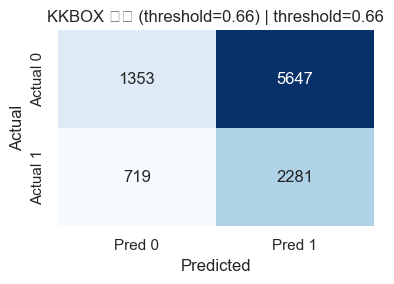

              precision    recall  f1-score   support

           0       0.65      0.19      0.30      7000
           1       0.29      0.76      0.42      3000

    accuracy                           0.36     10000
   macro avg       0.47      0.48      0.36     10000
weighted avg       0.54      0.36      0.33     10000


=== KKBOX 전이 (best threshold=0.25) 평가 결과 (threshold=0.25) ===


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.25,0.2964,0.2974,0.9873,0.4571,0.574


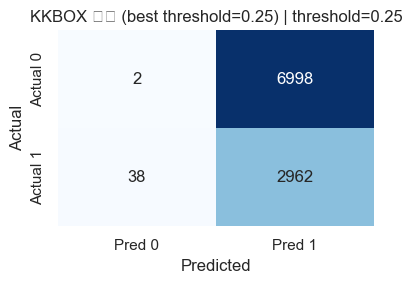

              precision    recall  f1-score   support

           0       0.05      0.00      0.00      7000
           1       0.30      0.99      0.46      3000

    accuracy                           0.30     10000
   macro avg       0.17      0.49      0.23     10000
weighted avg       0.12      0.30      0.14     10000



In [10]:
prob_kkbox_transfer = stacking.predict_proba(X_kkbox_aligned)[:, 1]

# 최적 threshold 탐색
best_th_transfer, thresh_df_transfer = find_best_threshold(
    y_kkbox, prob_kkbox_transfer, metric='f1'
)

# 06 기준 threshold=0.66 평가
metrics_transfer = evaluate(
    y_kkbox, prob_kkbox_transfer,
    threshold=0.66, label='KKBOX 전이 (threshold=0.66)'
)

# 최적 threshold 평가
metrics_transfer_best = evaluate(
    y_kkbox, prob_kkbox_transfer,
    threshold=best_th_transfer, label=f'KKBOX 전이 (best threshold={best_th_transfer})'
)

---
# 실험 B. KKBOX 단독 학습 / 예측

KKBOX 데이터만으로 동일한 Stacking 파이프라인을 학습해 실제 데이터에서의 성능 상한을 확인한다.

## B-1. KKBOX 전체 데이터 로드 (더 많은 샘플)

In [11]:
print('[KKBOX 단독 학습용]')
df_kkbox_full = sample_by_churn_ratio(
    df_kkbox_ori, n_total=50000, churn_ratio=0.3
)

[KKBOX 단독 학습용]
샘플링 완료 | 총 50,000행 | 이탈 15,000명(30.0%) | 유지 35,000명(70.0%)


## B-2. 전처리 및 학습

In [12]:
# KKBOX 자체 LabelEncoder로 fit
X_kkbox_full, y_kkbox_full, le_dict_kkbox = preprocess(df_kkbox_full, fit=True)

# 학습 / 테스트 분할
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kkbox_full, y_kkbox_full,
    test_size=0.3, random_state=2026, stratify=y_kkbox_full
)

# BorderlineSMOTE
X_res_k, y_res_k = BorderlineSMOTE(random_state=42).fit_resample(X_train_k, y_train_k)
print(f'KKBOX 학습 데이터: {X_res_k.shape} | 이탈: {y_res_k.sum()}')

KKBOX 학습 데이터: (49000, 14) | 이탈: 24500


In [13]:
# Stacking 모델 학습 (KKBOX 단독)
print('KKBOX Stacking 학습 중...')
stacking_kkbox = build_stacking()
stacking_kkbox.fit(X_res_k, y_res_k)
print('학습 완료')

KKBOX Stacking 학습 중...
학습 완료


## B-3. KKBOX 단독 예측 평가


최적 threshold (f1 기준): 0.75


,threshold,precision,recall,f1,roc_auc
0,0.25,0.696205,0.974222,0.812077,0.97702
1,0.30,0.701588,0.971778,0.814870,0.97702
2,0.35,0.711256,0.968889,0.820320,0.97702
3,0.40,0.719993,0.965111,0.824725,0.97702
4,0.45,0.732001,0.960222,0.830722,0.97702
5,0.50,0.749563,0.952444,0.838912,0.97702
6,0.55,0.770078,0.948222,0.849915,0.97702
7,0.60,0.783829,0.943556,0.856307,0.97702
8,0.65,0.794910,0.937111,0.860173,0.97702
9,0.70,0.815270,0.927778,0.867893,0.97702



=== KKBOX 단독 (threshold=0.66) 평가 결과 (threshold=0.66) ===


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.66,0.9121,0.8044,0.934,0.8644,0.977


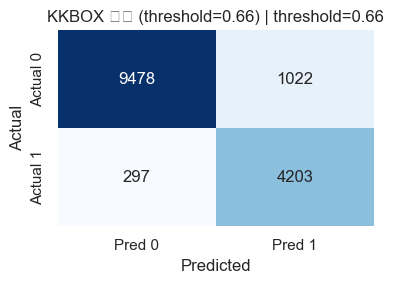

              precision    recall  f1-score   support

           0       0.97      0.90      0.93     10500
           1       0.80      0.93      0.86      4500

    accuracy                           0.91     15000
   macro avg       0.89      0.92      0.90     15000
weighted avg       0.92      0.91      0.91     15000


=== KKBOX 단독 (best threshold=0.75) 평가 결과 (threshold=0.75) ===


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.75,0.9258,0.8507,0.9129,0.8807,0.977


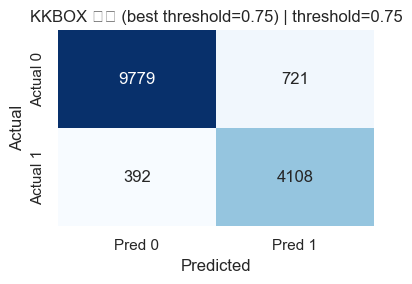

              precision    recall  f1-score   support

           0       0.96      0.93      0.95     10500
           1       0.85      0.91      0.88      4500

    accuracy                           0.93     15000
   macro avg       0.91      0.92      0.91     15000
weighted avg       0.93      0.93      0.93     15000



In [14]:
prob_kkbox_indomain = stacking_kkbox.predict_proba(X_test_k)[:, 1]

# 최적 threshold 탐색
best_th_k, thresh_df_k = find_best_threshold(
    y_test_k, prob_kkbox_indomain, metric='f1'
)

# 06 기준 threshold=0.66 평가
metrics_indomain = evaluate(
    y_test_k, prob_kkbox_indomain,
    threshold=0.66, label='KKBOX 단독 (threshold=0.66)'
)

# 최적 threshold 평가
metrics_indomain_best = evaluate(
    y_test_k, prob_kkbox_indomain,
    threshold=best_th_k, label=f'KKBOX 단독 (best threshold={best_th_k})'
)

---
# 실험 A vs B 최종 비교

,threshold,accuracy,precision,recall,f1,roc_auc
실험,,,,,,
A. Netflix 기준 (th=0.66),0.66,0.8353,0.7377,0.7000,0.7184,0.8953
A. KKBOX 전이 (th=0.66),0.66,0.3634,0.2877,0.7603,0.4175,0.5740
A. KKBOX 전이 (best th=0.25),0.25,0.2964,0.2974,0.9873,0.4571,0.5740
B. KKBOX 단독 (th=0.66),0.66,0.9121,0.8044,0.9340,0.8644,0.9770
B. KKBOX 단독 (best th=0.75),0.75,0.9258,0.8507,0.9129,0.8807,0.9770


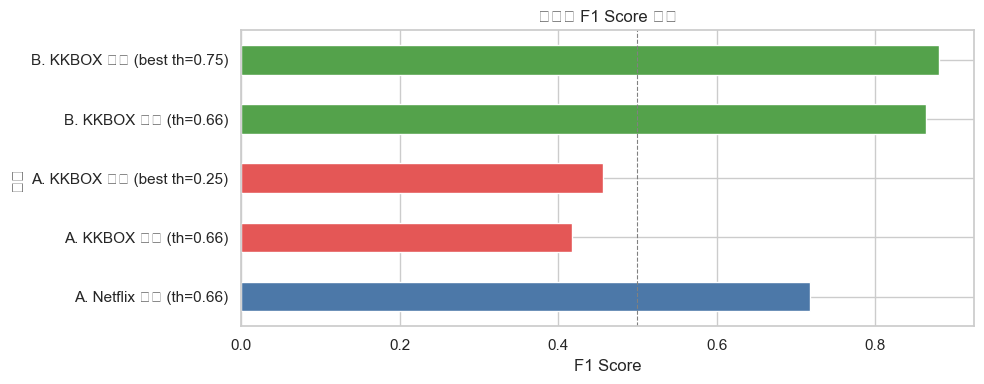

In [15]:
comparison = pd.DataFrame([
    {'실험': 'A. Netflix 기준 (th=0.66)',       **metrics_net},
    {'실험': 'A. KKBOX 전이 (th=0.66)',         **metrics_transfer},
    {'실험': f'A. KKBOX 전이 (best th={best_th_transfer})', **metrics_transfer_best},
    {'실험': 'B. KKBOX 단독 (th=0.66)',         **metrics_indomain},
    {'실험': f'B. KKBOX 단독 (best th={best_th_k})',        **metrics_indomain_best},
]).set_index('실험')

display(comparison)

# F1 비교 시각화
fig, ax = plt.subplots(figsize=(10, 4))
comparison['f1'].plot(kind='barh', ax=ax, color=['#4C78A8','#E45756','#E45756','#54A24B','#54A24B'])
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('F1 Score')
ax.set_title('실험별 F1 Score 비교')
plt.tight_layout()
plt.show()

## 결과 저장 (선택)

In [16]:
output_dir = project_output_dir()

# 전이 예측 결과 저장
transfer_result = df_kkbox.copy()
transfer_result['churn_probability'] = prob_kkbox_transfer
transfer_result['predicted']         = (prob_kkbox_transfer >= best_th_transfer).astype(int)
transfer_result['experiment']        = 'transfer'
transfer_result.to_csv(output_dir / 'kkbox_transfer_result.csv', index=False)

# 단독 예측 결과 저장
indomain_result = df_kkbox_full.iloc[X_test_k.index].copy()
indomain_result['churn_probability'] = prob_kkbox_indomain
indomain_result['predicted']         = (prob_kkbox_indomain >= best_th_k).astype(int)
indomain_result['experiment']        = 'indomain'
indomain_result.to_csv(output_dir / 'kkbox_indomain_result.csv', index=False)

# 비교표 저장
comparison.to_csv(output_dir / 'experiment_comparison.csv')

print('저장 완료')
print(f'  outputs/kkbox_transfer_result.csv')
print(f'  outputs/kkbox_indomain_result.csv')
print(f'  outputs/experiment_comparison.csv')

저장 완료
  outputs/kkbox_transfer_result.csv
  outputs/kkbox_indomain_result.csv
  outputs/experiment_comparison.csv
